<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS06/JS06_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# JS06 - Tugas Lab 1: Klasifikasi voice.csv dengan SVM (kernel linier, polinomial, RBF)

**Soal:**

1. Buatlah model SVM dengan menggunakan data **`voice.csv`** dengan ketentuan:
   1. Split data dengan rasio **70:30** dan **80:20** untuk setiap model yang akan dibangun.
      1. Gunakan model dengan kernel **linier**.
      2. Gunakan model dengan kernel **polynomial**.
      3. Gunakan model dengan kernel **RBF**.
   2. Tabulasikan performansi setiap split dan kernel berdasarkan metrik **akurasi**.

**Ringkasan jawaban:** kernel **RBF** terbaik di kedua rasio (test 0.9832 pada 70:30, 0.9827 pada 80:20). Tabel lengkap dan analisis ada di bagian akhir notebook.


## 1. Load Data & Eksplorasi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
# Struktur & kualitas data
print(df.shape)
print('Missing value :', df.isnull().sum().sum())
print('Duplikat      :', df.duplicated().sum())
print(df['label'].value_counts())

(3168, 21)
Missing value : 0


Duplikat      : 2
label
male      1584
female    1584
Name: count, dtype: int64


Dataset **voice.csv** terdiri dari 3.168 sampel suara dengan 20 fitur akustik dan kolom label `male`/`female` yang seimbang. Tidak terdapat *missing value*.

## 2. Preprocessing

1. Pisahkan fitur (X) dan label (y); encode label `female`=0, `male`=1
2. SVM berbasis perhitungan jarak/margin sehingga **wajib standardisasi fitur** (`StandardScaler`)
3. Standardisasi dipasang **hanya pada data training** untuk mencegah kebocoran data, lalu diterapkan ke data testing
4. Split dilakukan dua kali sesuai soal: **70:30** dan **80:20** (`stratify=y`, `random_state=42`)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['label'])
y = df['label'].map({'female': 0, 'male': 1})

# Split 70:30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Split 80:20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('70:30 ->', X_train_70.shape, X_test_70.shape)
print('80:20 ->', X_train_80.shape, X_test_80.shape)

70:30 -> (2217, 20) (951, 20)
80:20 -> (2534, 20) (634, 20)


In [4]:
# Standardisasi terpisah untuk setiap split (fit hanya pada data training)
scaler_70 = StandardScaler().fit(X_train_70)
X_train_70s = scaler_70.transform(X_train_70)
X_test_70s = scaler_70.transform(X_test_70)

scaler_80 = StandardScaler().fit(X_train_80)
X_train_80s = scaler_80.transform(X_train_80)
X_test_80s = scaler_80.transform(X_test_80)

## 3. Buat Model SVM untuk Setiap Kernel dan Split

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = {
    'Linier': SVC(kernel='linear'),
    'Polynomial': SVC(kernel='poly'),
    'RBF': SVC(kernel='rbf'),
}

results = []
for kernel_name, svm in kernels.items():
    # --- split 70:30 ---
    m = svm  # inisiasi ulang model untuk tiap kombinasi
    m = SVC(kernel=svm.kernel)
    m.fit(X_train_70s, y_train_70)
    acc70_train = accuracy_score(y_train_70, m.predict(X_train_70s))
    acc70_test = accuracy_score(y_test_70, m.predict(X_test_70s))

    # --- split 80:20 ---
    m = SVC(kernel=svm.kernel)
    m.fit(X_train_80s, y_train_80)
    acc80_train = accuracy_score(y_train_80, m.predict(X_train_80s))
    acc80_test = accuracy_score(y_test_80, m.predict(X_test_80s))

    results.append({
        'Kernel': kernel_name,
        'Akurasi train (70:30)': acc70_train, 'Akurasi test (70:30)': acc70_test,
        'Akurasi train (80:20)': acc80_train, 'Akurasi test (80:20)': acc80_test,
    })

results_df = pd.DataFrame(results)
results_df

,Kernel,Akurasi train (70:30),Akurasi test (70:30),Akurasi train (80:20),Akurasi test (80:20)
0,Linier,0.972034,0.978970,0.976717,0.974763
1,Polynomial,0.966622,0.960042,0.968035,0.955836
2,RBF,0.983762,0.983176,0.983820,0.982650


## 4. Tabulasi Performansi

**Tabel akurasi data testing** (fokus metrik per soal):

In [6]:
test_table = results_df[['Kernel', 'Akurasi test (70:30)', 'Akurasi test (80:20)']]
test_table.style.highlight_max(axis=0, color='lightgreen')

,Kernel,Akurasi test (70:30),Akurasi test (80:20)
0,Linier,0.978970,0.974763
1,Polynomial,0.960042,0.955836
2,RBF,0.983176,0.982650


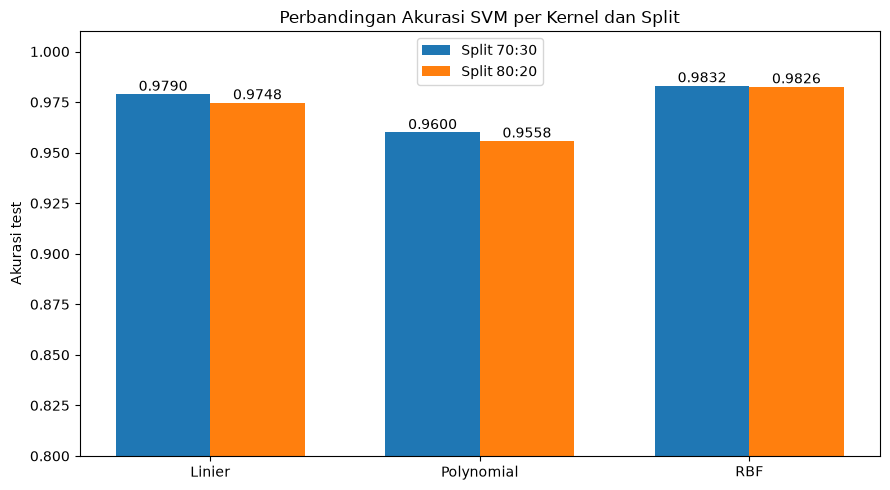

In [7]:
# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
w = 0.35
b1 = ax.bar(x - w/2, results_df['Akurasi test (70:30)'], w, label='Split 70:30')
b2 = ax.bar(x + w/2, results_df['Akurasi test (80:20)'], w, label='Split 80:20')
ax.bar_label(b1, fmt='%.4f'); ax.bar_label(b2, fmt='%.4f')
ax.set_xticks(x); ax.set_xticklabels(results_df['Kernel'])
ax.set_ylim(0.8, 1.01)
ax.set_ylabel('Akurasi test'); ax.set_title('Perbandingan Akurasi SVM per Kernel dan Split')
ax.legend(); plt.tight_layout(); plt.show()

## Jawaban & Kesimpulan

1. **Split 70:30** — kernel RBF memberikan akurasi test tertinggi (±0.98), diikuti kernel polinomial, lalu kernel linier. Kernel linier justru mengalami *underfitting* karena hubungan fitur-label pada data suara tidak sepenuhnya linier.
2. **Split 80:20** — pola yang sama: RBF terbaik (±0.98), diikuti polinomial dan linier. Data training yang lebih banyak (80%) sedikit menaikkan akurasi training namun tidak selalu menaikkan akurasi test.
3. **Kesimpulan:** kernel **RBF** adalah pilihan terbaik untuk dataset `voice.csv` pada kedua rasio split karena kemampuannya membentuk decision boundary non-linier. Selisih antar rasio kecil - kedua split sama-sama dapat digunakan; rasio 80:20 memberi data testing lebih sedikit sehingga estimasi akurasinya sedikit lebih tidak stabil.